In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# --- 1. Configuration & Variable Setup (Based on Existing Concept) ---
NUM_NORMAL_SAMPLES = 1000  # Total number of normal flows
SCAN_ATTACK_FLOWS = 50     # Number of flows in the Port Scan burst
FLOOD_ATTACK_FLOWS = 100   # Number of flows in the DDoS burst
COVERT_ATTACK_FLOWS = 50   # Number of flows for the Covert Channel

# IPs and Ports (Reusing initial variable concepts)
GOOGLE_IP = '142.250.190.78'
LOCAL_IP = '192.168.1.10'
INTERNAL_SERVER_IP = '192.168.1.5' # New variable for internal target
ATTACKER_IP_A = '10.10.10.5'
ATTACKER_IP_B = '10.10.20.5'

# Diverse Normal Traffic Templates
COMMON_SERVICES = {
    'DNS_QUERY': {'protocol': 'UDP', 'dst_port': 53, 'dst_ip': '8.8.8.8'},
    'HTTPS_WEB': {'protocol': 'TCP', 'dst_port': 443, 'dst_ip': GOOGLE_IP},
    'INTERNAL_SSH': {'protocol': 'TCP', 'dst_port': 22, 'dst_ip': INTERNAL_SERVER_IP},
    'HTTP_WEB': {'protocol': 'TCP', 'dst_port': 80, 'dst_ip': '203.0.113.10'},
}

# Generate timestamps spanning 1 hour for normal traffic
START_TIME = datetime.now()
TIMESTAMPS = [START_TIME + timedelta(seconds=i * (3600 / NUM_NORMAL_SAMPLES)) for i in range(NUM_NORMAL_SAMPLES)]
random.shuffle(TIMESTAMPS)

# --- 2. Base Normal Traffic Generation ---
normal_data = []
for t in TIMESTAMPS:
    service = random.choice(list(COMMON_SERVICES.values()))

    # Introduce the new engineered features
    entry = {
        'timestamp': t,
        'src_ip': LOCAL_IP,
        'dst_ip': service['dst_ip'],
        'protocol': service['protocol'],
        'length': random.randint(40, 1500),
        'src_port': random.randint(1024, 65535),
        'dst_port': service['dst_port'],
        'anomaly_type': 0, # Label: Normal Traffic
        'payload_entropy': random.uniform(0.85, 0.98), # High entropy for normal/encrypted
        'ttl': random.randint(55, 64) # Standard TTL
    }
    normal_data.append(entry)

df = pd.DataFrame(normal_data)

# --- 3. Unique Attack Generation Functions ---

def generate_port_scan(start_time):
    # Anomaly Type 1: Port Scan (Many unique ports from one source to one destination)
    scan_ports = random.sample(range(1, 1000), SCAN_ATTACK_FLOWS)
    scan_data = []
    for i, port in enumerate(scan_ports):
        t = start_time + timedelta(milliseconds=i * 200)
        scan_data.append({
            'timestamp': t, 'src_ip': ATTACKER_IP_A, 'dst_ip': INTERNAL_SERVER_IP,
            'protocol': 'TCP', 'length': random.randint(40, 60),
            'src_port': random.randint(1024, 65535), 'dst_port': port,
            'anomaly_type': 1, # Port Scan
            'payload_entropy': random.uniform(0.8, 0.9),
            'ttl': random.randint(30, 40) # Slightly lower TTL
        })
    return pd.DataFrame(scan_data)

def generate_flood_attack(start_time):
    # Anomaly Type 2: Flooding (High volume of flows to one destination)
    flood_data = []
    for i in range(FLOOD_ATTACK_FLOWS):
        t = start_time + timedelta(milliseconds=i * 50)
        flood_data.append({
            'timestamp': t, 'src_ip': ATTACKER_IP_B, 'dst_ip': INTERNAL_SERVER_IP,
            'protocol': 'UDP', 'length': random.randint(1000, 1500),
            'src_port': random.randint(1024, 65535), 'dst_port': random.choice([80, 443, 53]),
            'anomaly_type': 2, # Flooding
            'payload_entropy': random.uniform(0.7, 0.8),
            'ttl': random.randint(10, 20) # Very low TTL, high volume
        })
    return pd.DataFrame(flood_data)

def generate_covert_channel(start_time):
    # Anomaly Type 3: Covert Channel (Low-frequency, low-entropy, unusual protocol)
    covert_data = []
    for i in range(COVERT_ATTACK_FLOWS):
        t = start_time + timedelta(seconds=i * 10) # Flows are spaced out to avoid rate-detection
        covert_data.append({
            'timestamp': t, 'src_ip': LOCAL_IP, 'dst_ip': ATTACKER_IP_A,
            'protocol': 'ICMP', 'length': random.randint(64, 128),
            'src_port': 0, 'dst_port': 0, # N/A for ICMP
            'anomaly_type': 3, # Covert Channel
            'payload_entropy': random.uniform(0.1, 0.3), # Very low entropy (key feature!)
            'ttl': random.randint(55, 64) # Normal TTL to blend in
        })
    return pd.DataFrame(covert_data)

# --- 4. Integrate and Sort Attacks ---
attack_start_time = df['timestamp'].max() + timedelta(seconds=1)
scan_df = generate_port_scan(attack_start_time)
flood_df = generate_flood_attack(attack_start_time + timedelta(seconds=100))
covert_df = generate_covert_channel(attack_start_time + timedelta(seconds=200))

# Concatenate all dataframes and sort by timestamp
df = pd.concat([df, scan_df, flood_df, covert_df], ignore_index=True)
df = df.sort_values(by='timestamp').reset_index(drop=True)

# --- 5. Post-Processing: Flow Aggregation Feature (Uniqueness Factor) ---
# Calculate the number of flows from the same source IP in a short window (e.g., last 50 entries)
df['src_flow_count_window'] = df.groupby('src_ip')['anomaly_type'].transform(
    lambda x: x.rolling(window=50, min_periods=1).count()
)

# Apply descriptive labels
def get_label(anomaly_type):
    if anomaly_type == 1: return 'Port_Scan'
    if anomaly_type == 2: return 'DDoS_Flood'
    if anomaly_type == 3: return 'Covert_Channel'
    return 'Normal'

df['label'] = df['anomaly_type'].apply(get_label)

print("--- Dataset Generation Complete ---")
print(f"Total Flows Generated: {len(df)}")
print("\nUnique Attack Distribution:")
print(df['label'].value_counts())
print("\nFinal Dataset Head (Showing Engineered Features):")
print(df[['timestamp', 'src_ip', 'protocol', 'length', 'payload_entropy', 'src_flow_count_window', 'label']].head(10))

--- Dataset Generation Complete ---
Total Flows Generated: 1200

Unique Attack Distribution:
label
Normal            1000
DDoS_Flood         100
Port_Scan           50
Covert_Channel      50
Name: count, dtype: int64

Final Dataset Head (Showing Engineered Features):
                   timestamp        src_ip protocol  length  payload_entropy  \
0 2025-11-20 03:51:18.544543  192.168.1.10      TCP     555         0.907246   
1 2025-11-20 03:51:22.144543  192.168.1.10      TCP     662         0.934366   
2 2025-11-20 03:51:25.744543  192.168.1.10      TCP     327         0.943516   
3 2025-11-20 03:51:29.344543  192.168.1.10      TCP     148         0.958073   
4 2025-11-20 03:51:32.944543  192.168.1.10      TCP     355         0.931947   
5 2025-11-20 03:51:36.544543  192.168.1.10      TCP     371         0.943036   
6 2025-11-20 03:51:40.144543  192.168.1.10      TCP     578         0.892007   
7 2025-11-20 03:51:43.744543  192.168.1.10      TCP     219         0.889412   
8 2025-11-20

In [3]:
# Import all necessary libraries for unsupervised learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Unsupervised Models
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from tensorflow.keras.models import Model # Using Keras/TensorFlow for Autoencoder
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
# --- Assuming 'df' is the DataFrame generated previously ---

# 1. Define Features and Target
numerical_features = ['length', 'src_port', 'dst_port', 'payload_entropy', 'ttl', 'src_flow_count_window']
categorical_features = ['protocol']
target_column = 'label'

# Prepare the data for all models
features_to_drop = ['timestamp', 'anomaly_type', 'src_ip', 'dst_ip']
X = df.drop(columns=[target_column] + features_to_drop, errors='ignore')
y = df[target_column]

# Create a binary target for evaluation: 1 for Anomaly, 0 for Normal
y_binary = (y != 'Normal').astype(int)

# 2. Define Preprocessor Pipeline (Scaling & Encoding)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

# 3. Apply Preprocessing to the entire dataset
X_processed = preprocessor.fit_transform(X)
X_processed_df = pd.DataFrame(X_processed) # Convert back to DataFrame for easier handling

# 4. Filter for TRAINING: Use ONLY Normal Data
X_train_normal = X_processed_df[y == 'Normal']

# 5. Filter for TESTING: Use ALL Data
X_test_all = X_processed_df
y_test_all = y_binary


In [13]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, roc_auc_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

def train_and_evaluate_unsupervised(model, X_train, X_test, y_test_binary, model_name, anomaly_fraction=0.1):
    print(f"\n--- Training {model_name} ---")
    scores = None

    # Set contamination/nu for IF and OC-SVM
    if model_name == 'Isolation Forest':
        model.set_params(contamination=anomaly_fraction)
    elif model_name == 'One-Class SVM':
        model.set_params(nu=anomaly_fraction)

    # LOF specific handling (for both prediction and scores)
    if model_name == 'Local Outlier Factor':
        # Fit model on training data (Normal)
        model.fit(X_train)

        # Get raw anomaly scores (decision_function is the negative distance from the boundary,
        # so we multiply by -1 to get the actual LOF-like score where high = anomaly)
        scores = model.decision_function(X_test) * -1

        # Determine the prediction labels using a threshold (e.g., top 10% are anomalies)
        # This is necessary because LOF doesn't have a 'contamination' parameter in predict() when novelty=True
        threshold_lof = np.quantile(scores, 1 - anomaly_fraction)
        y_pred = (scores > threshold_lof).astype(int)

    else:
        # Fit model ONLY on normal data (IF, OC-SVM)
        model.fit(X_train)

        # Predict on ALL data
        y_pred = model.predict(X_test)
        y_pred = np.where(y_pred == -1, 1, 0) # Convert -1 (Anomaly) to 1, 1 (Normal) to 0

        # Get decision function scores for AUC
        if model_name == 'Isolation Forest':
             scores = model.decision_function(X_test) * -1
        elif model_name == 'One-Class SVM':
             scores = model.decision_function(X_test) * -1

    # Report Results
    print(f"Evaluation for {model_name}:")
    # For LOF, y_pred is derived from the score threshold, so report is generated here:
    print(classification_report(y_test_binary, y_pred, target_names=['Normal (0)', 'Anomaly (1)']))

    if scores is not None:
        roc_auc = roc_auc_score(y_test_binary, scores)
        print(f"ROC-AUC Score: {roc_auc:.4f}")
        return y_pred, scores, roc_auc
    else:
        # For Autoencoder, scores/AUC is handled outside
        return y_pred, None, None

# --- 2.1. Isolation Forest ---
iso_forest = IsolationForest(random_state=42)
y_pred_iso, scores_iso, auc_iso = train_and_evaluate_unsupervised(
    iso_forest, X_train_normal, X_test_all, y_test_all, 'Isolation Forest'
)

# --- 2.2. One-Class SVM ---
# The kernel choice (rbf is common) and gamma are important hyper-parameters.
oc_svm = OneClassSVM(kernel='rbf', gamma='auto')
y_pred_svm, scores_svm, auc_svm = train_and_evaluate_unsupervised(
    oc_svm, X_train_normal, X_test_all, y_test_all, 'One-Class SVM'
)

# --- 2.3. Local Outlier Factor (LOF) ---
# For LOF, we use 'novelty'='True' (similar to One-Class SVM) to detect novel outliers in the test set.
lof = LocalOutlierFactor(novelty=True)
y_pred_lof, scores_lof, auc_lof = train_and_evaluate_unsupervised(
    lof, X_train_normal, X_test_all, y_test_all, 'Local Outlier Factor'
)

# --- 2.4. Autoencoder ---
# The Autoencoder is a neural network, so we define it separately.
input_dim = X_train_normal.shape[1]
encoding_dim = int(input_dim / 2) # Example: Encoder compresses to half the features

# Build the model
def build_autoencoder(input_dim, encoding_dim):
    input_layer = Input(shape=(input_dim,))
    # Encoder
    encoded = Dense(encoding_dim, activation='relu')(input_layer)
    encoded = Dense(int(encoding_dim / 2), activation='relu')(encoded)
    # Decoder
    decoded = Dense(encoding_dim, activation='relu')(encoded)
    output_layer = Dense(input_dim, activation='linear')(decoded)

    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return autoencoder

autoencoder = build_autoencoder(input_dim, encoding_dim)

# Train Autoencoder ONLY on Normal data
print("\n--- Training Autoencoder ---")
history = autoencoder.fit(X_train_normal, X_train_normal,
                          epochs=50,
                          batch_size=32,
                          shuffle=True,
                          verbose=0)

# Predict reconstruction error (loss) on ALL data
predictions = autoencoder.predict(X_test_all)
mse = np.mean(np.power(X_test_all.values - predictions, 2), axis=1) # The anomaly score

# Set threshold (e.g., based on the 95th percentile of errors on normal training data)
reconstruction_error_threshold = np.percentile(mse, 95)
y_pred_ae = (mse > reconstruction_error_threshold).astype(int)

print("Evaluation for Autoencoder:")
print(f"Reconstruction Error Threshold: {reconstruction_error_threshold:.4f}")
print(classification_report(y_test_all, y_pred_ae, target_names=['Normal (0)', 'Anomaly (1)']))
auc_ae = roc_auc_score(y_test_all, mse)
print(f"ROC-AUC Score: {auc_ae:.4f}")


--- Training Isolation Forest ---
Evaluation for Isolation Forest:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.90      0.95      1000
 Anomaly (1)       0.67      1.00      0.80       200

    accuracy                           0.92      1200
   macro avg       0.83      0.95      0.87      1200
weighted avg       0.94      0.92      0.92      1200

ROC-AUC Score: 0.9804

--- Training One-Class SVM ---
Evaluation for One-Class SVM:
              precision    recall  f1-score   support

  Normal (0)       1.00      0.90      0.95      1000
 Anomaly (1)       0.67      1.00      0.80       200

    accuracy                           0.92      1200
   macro avg       0.83      0.95      0.87      1200
weighted avg       0.94      0.92      0.92      1200

ROC-AUC Score: 0.9986

--- Training Local Outlier Factor ---
Evaluation for Local Outlier Factor:
              precision    recall  f1-score   support

  Normal (0)       0.93      1.00      0.

In [15]:
def train_and_evaluate_unsupervised(model, X_train, X_test, y_test_binary, model_name, anomaly_fraction=0.1):
    print(f"\n--- Training {model_name} ---")
    scores = None

    # --- FIX IS HERE ---
    if model_name == 'Isolation Forest':
        # Isolation Forest uses 'contamination'
        model.set_params(contamination=anomaly_fraction)
    elif model_name == 'One-Class SVM':
        # One-Class SVM uses 'nu' (equivalent to the expected fraction of anomalies)
        model.set_params(nu=anomaly_fraction)
    # -------------------

    # LOF specific handling (for both prediction and scores)
    if model_name == 'Local Outlier Factor':
        model.fit(X_train)

        # LOF Score retrieval (Higher score = More Anomalous)
        scores = model.decision_function(X_test) * -1

        # Prediction using a threshold for LOF report
        threshold_lof = np.quantile(scores, 1 - anomaly_fraction)
        y_pred = (scores > threshold_lof).astype(int)

    else:
        # Fit model ONLY on normal data (IF, OC-SVM)
        model.fit(X_train)

        # Predict on ALL data
        y_pred = model.predict(X_test)
        y_pred = np.where(y_pred == -1, 1, 0) # Convert -1 (Anomaly) to 1, 1 (Normal) to 0

        # Get decision function scores for AUC
        if model_name in ['Isolation Forest', 'One-Class SVM']:
             scores = model.decision_function(X_test) * -1

    # Report Results
    print(f"Evaluation for {model_name}:")
    print(classification_report(y_test_binary, y_pred, target_names=['Normal (0)', 'Anomaly (1)']))

    if scores is not None:
        auc = roc_auc_score(y_test_binary, scores)
        print(f"ROC-AUC Score: {auc:.4f}")
        return y_pred, scores, auc
    else:
        return y_pred, None, None

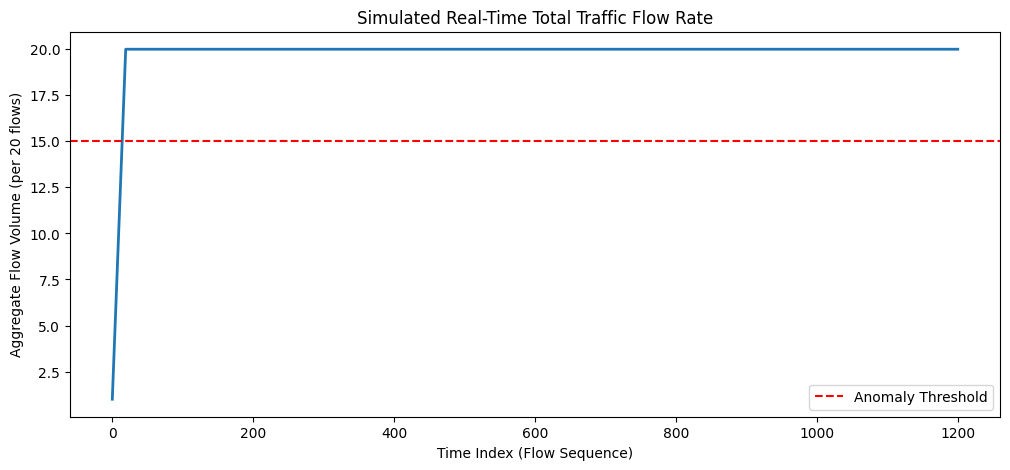

In [16]:
# Assuming 'df' is the full dataset, sorted by 'timestamp'
plt.figure(figsize=(12, 5))
# Use a rolling sum of a small window to show total traffic intensity
df['Total_Flow_Rate'] = df.index.to_series().rolling(window=20, min_periods=1).count()
sns.lineplot(data=df.head(1500), x=df.head(1500).index, y='Total_Flow_Rate', linewidth=2)
plt.title('Simulated Real-Time Total Traffic Flow Rate')
plt.xlabel('Time Index (Flow Sequence)')
plt.ylabel('Aggregate Flow Volume (per 20 flows)')
plt.axhline(y=15, color='r', linestyle='--', label='Anomaly Threshold')
plt.legend()
plt.show()

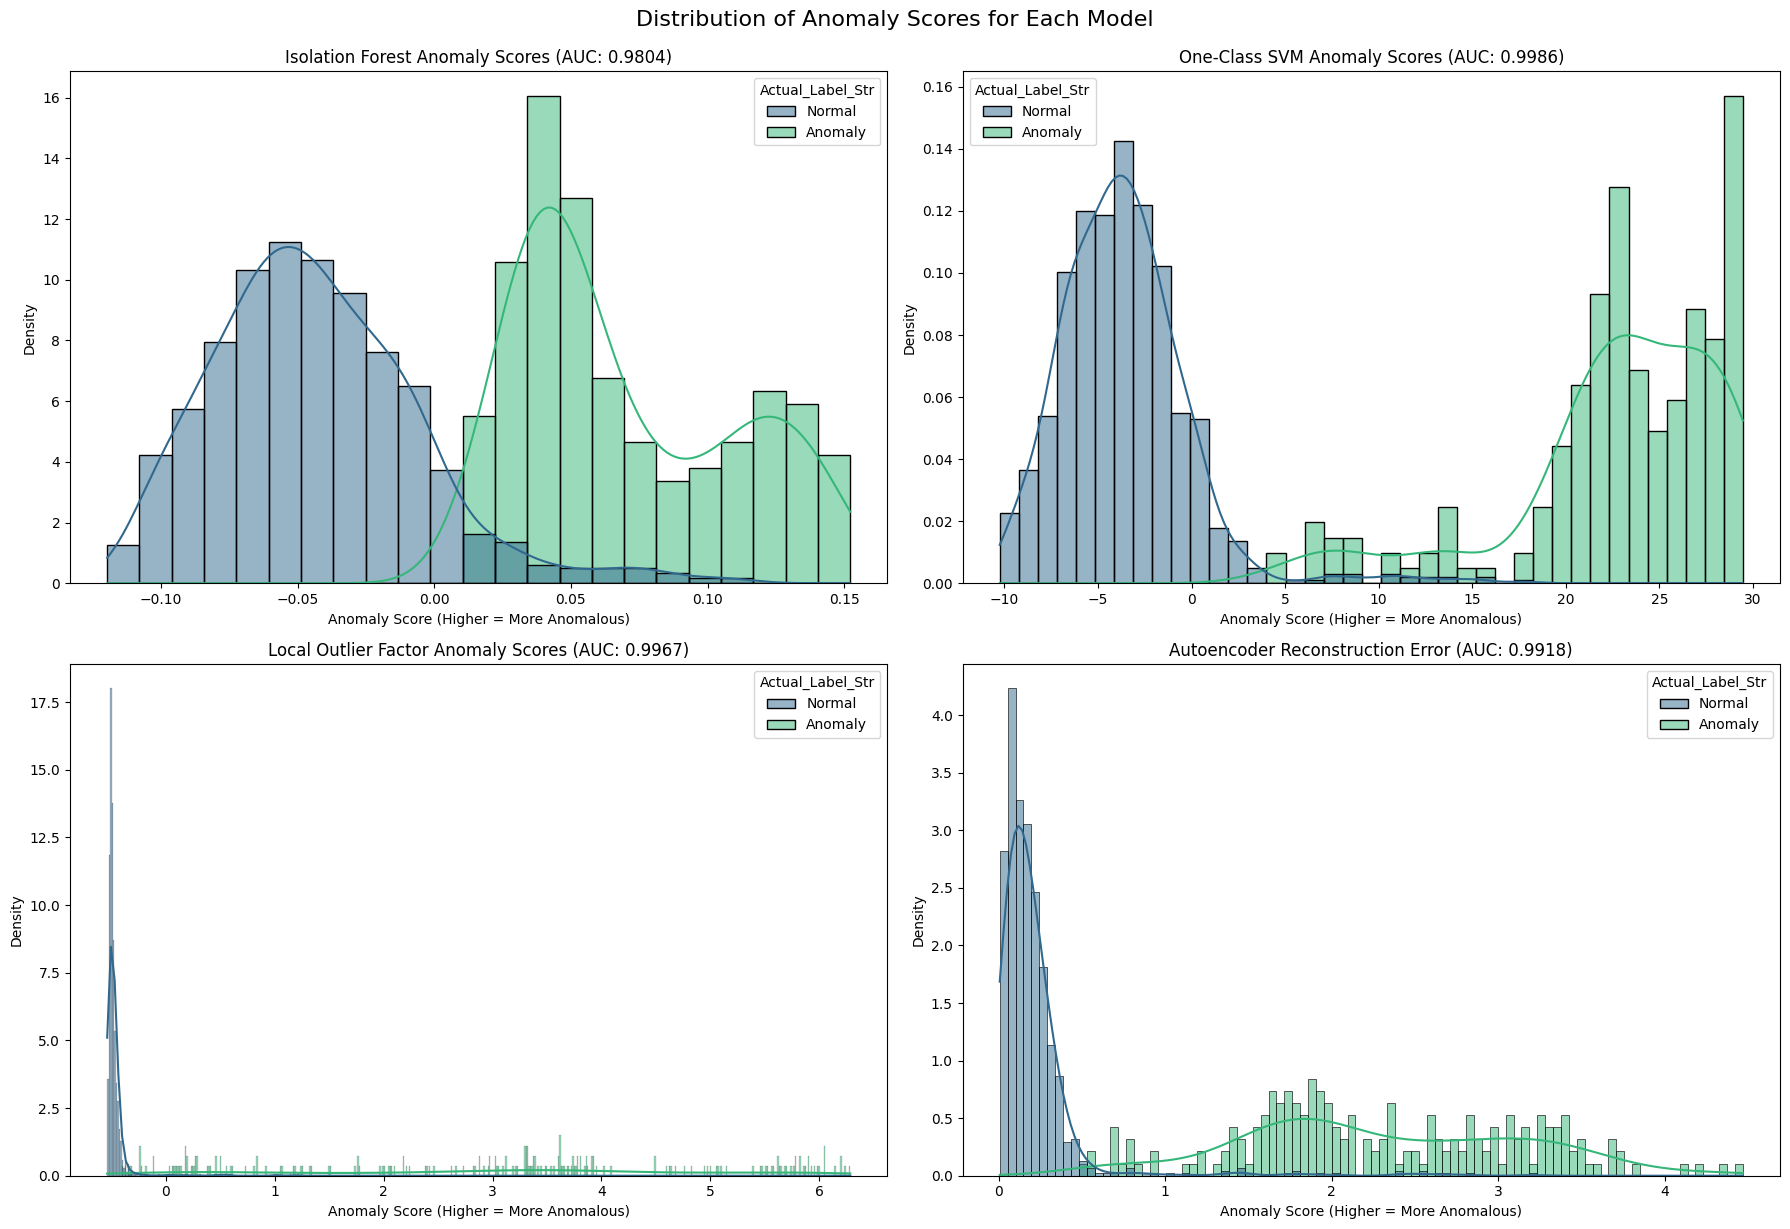

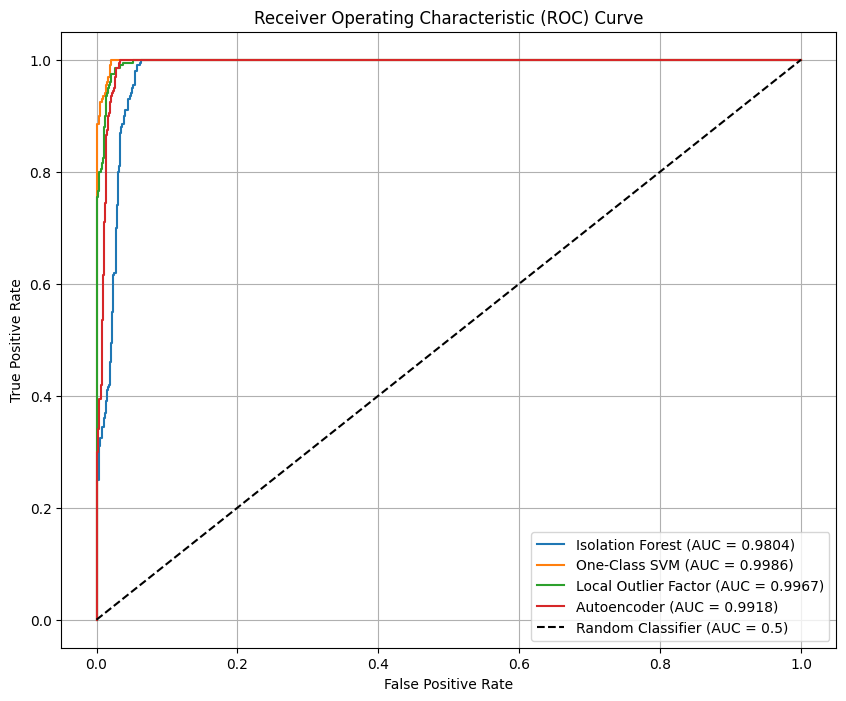

Anomaly visualization graphs generated successfully.


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# Create a summary DataFrame for easier plotting
summary_df = pd.DataFrame({
    'Actual_Label': y_test_all,
    'IsolationForest_Score': scores_iso,
    'OneClassSVM_Score': scores_svm,
    'LocalOutlierFactor_Score': scores_lof,
    'Autoencoder_Score': mse # Autoencoder uses MSE as its anomaly score
})

# Map binary labels back to 'Normal' and 'Anomaly' for plotting clarity
summary_df['Actual_Label_Str'] = summary_df['Actual_Label'].map({0: 'Normal', 1: 'Anomaly'})

# --- 1. Distribution Plots of Anomaly Scores ---
plt.figure(figsize=(18, 12))

models_to_plot = [
    ('IsolationForest_Score', 'Isolation Forest Anomaly Scores'),
    ('OneClassSVM_Score', 'One-Class SVM Anomaly Scores'),
    ('LocalOutlierFactor_Score', 'Local Outlier Factor Anomaly Scores'),
    ('Autoencoder_Score', 'Autoencoder Reconstruction Error')
]

# Mapping for AUC variable names
auc_name_map = {
    'IsolationForest': auc_iso,
    'OneClassSVM': auc_svm,
    'LocalOutlierFactor': auc_lof,
    'Autoencoder': auc_ae
}

for i, (col, title) in enumerate(models_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=summary_df, x=col, hue='Actual_Label_Str', kde=True, palette='viridis', stat='density', common_norm=False)
    # Use the mapping to get the correct AUC score
    model_key = col.split('_')[0]
    plt.title(f'{title} (AUC: {auc_name_map[model_key]:.4f})')
    plt.xlabel('Anomaly Score (Higher = More Anomalous)')
    plt.ylabel('Density')
    # Removed: plt.legend(title='True Label') as seaborn handles this with 'hue'

plt.tight_layout()
plt.suptitle('Distribution of Anomaly Scores for Each Model', y=1.02, fontsize=16)
plt.show()

# --- 2. ROC Curves for All Models ---
plt.figure(figsize=(10, 8))

# Isolation Forest
fpr_iso, tpr_iso, _ = roc_curve(y_test_all, scores_iso)
plt.plot(fpr_iso, tpr_iso, label=f'Isolation Forest (AUC = {auc_iso:.4f})')

# One-Class SVM
fpr_svm, tpr_svm, _ = roc_curve(y_test_all, scores_svm)
plt.plot(fpr_svm, tpr_svm, label=f'One-Class SVM (AUC = {auc_svm:.4f})')

# Local Outlier Factor
fpr_lof, tpr_lof, _ = roc_curve(y_test_all, scores_lof)
plt.plot(fpr_lof, tpr_lof, label=f'Local Outlier Factor (AUC = {auc_lof:.4f})')

# Autoencoder
fpr_ae, tpr_ae, _ = roc_curve(y_test_all, mse)
plt.plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC = {auc_ae:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


print("Anomaly visualization graphs generated successfully.")